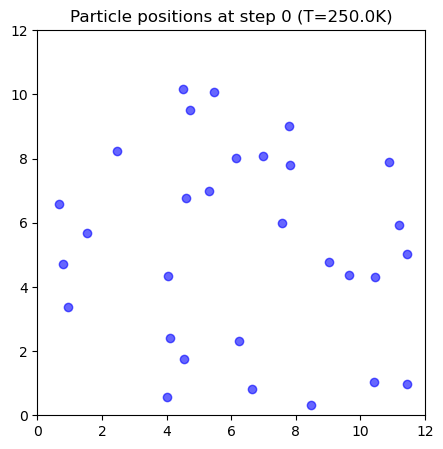

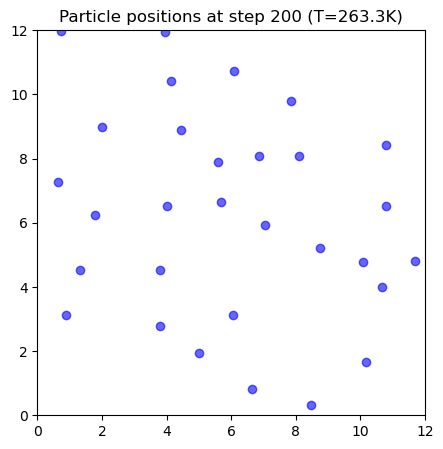

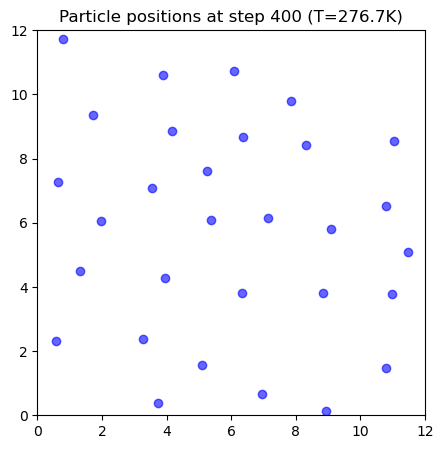

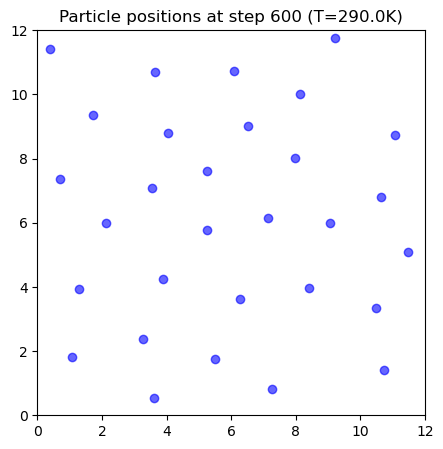

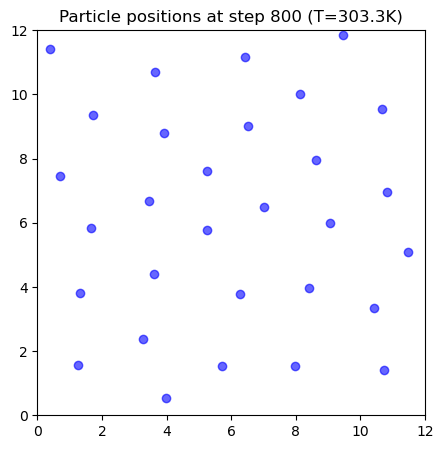

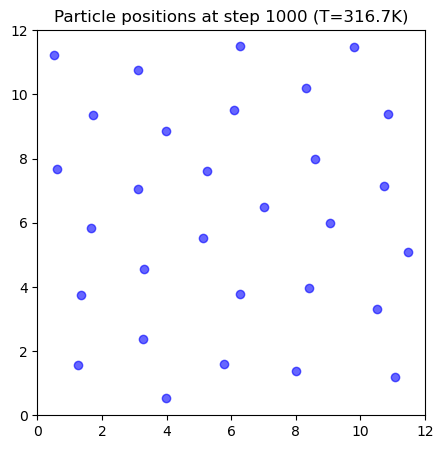

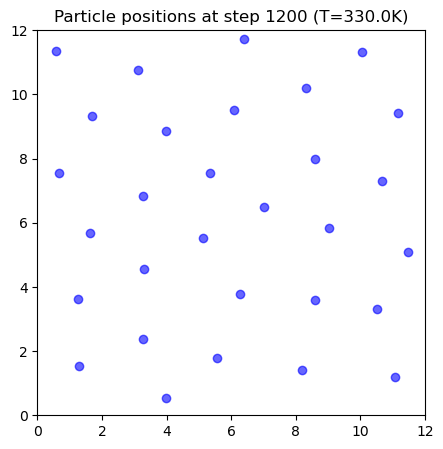

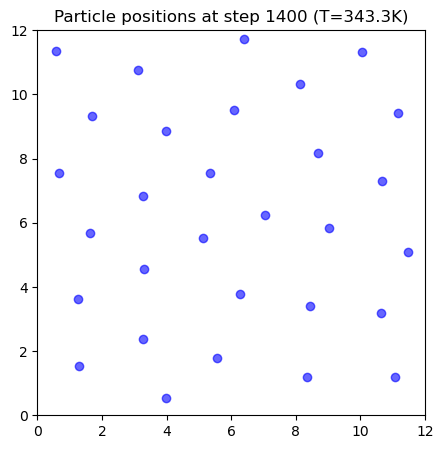

Acceptance ratio: 0.179


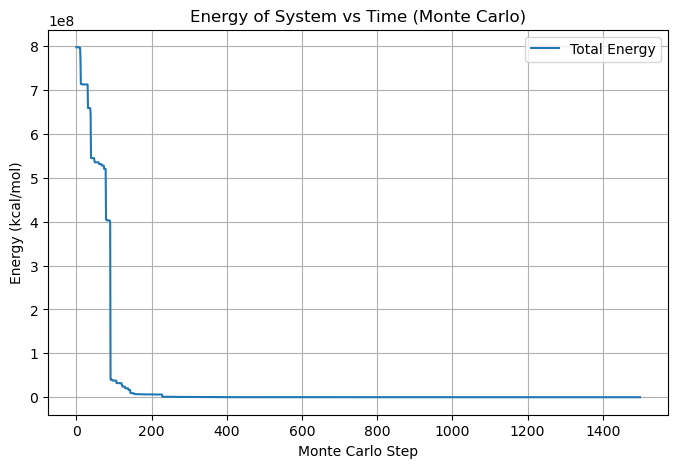

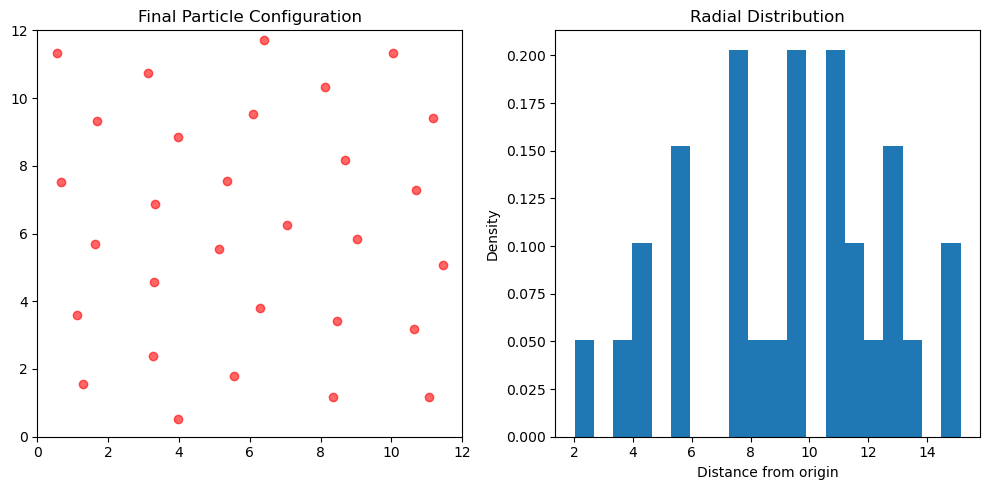

In [10]:
import numpy as np
import matplotlib.pyplot as plt

N = 30
L = 12.0
steps = 1500
step_size = 0.4
kB = 0.001987
T_initial = 250.0
T_final = 350.0
sigma = 3.5
epsilon = 0.25

coords = np.random.uniform(0, L, (N, 2))

def pbc(x):
    return x % L

def lennard_jones(r):
    sr6 = (sigma / r)**6
    sr12 = sr6 * sr6
    return 4 * epsilon * (sr12 - sr6)

def total_energy(coords):
    E = 0.0
    for i in range(N):
        for j in range(i+1, N):
            dx = coords[i,0] - coords[j,0]
            dy = coords[i,1] - coords[j,1]
            dx -= L * np.round(dx / L)
            dy -= L * np.round(dy / L)
            r = np.sqrt(dx*dx + dy*dy)
            if r > 0:
                E += lennard_jones(r)
    return E

energies = []
acceptance_count = 0
old_energy = total_energy(coords)
coords_history = []

for step in range(steps):
    T = T_initial + (T_final - T_initial) * step / steps
    old_coords = np.copy(coords)
    idx = np.random.randint(N)
    move = (np.random.uniform(-step_size, step_size, 2))
    coords[idx] = pbc(coords[idx] + move)
    new_energy = total_energy(coords)
    accept = False
    if new_energy <= old_energy:
        accept = True
        acceptance_count += 1
    else:
        prob = np.exp(-(new_energy - old_energy)/(kB*T))
        if np.random.uniform(0,1) < prob:
            accept = True
            acceptance_count += 1
    if accept:
        old_energy = new_energy
        coords_history.append(np.copy(coords))
    else:
        coords = old_coords
    energies.append(old_energy)
    if step % 200 == 0:
        plt.figure(figsize=(5,5))
        plt.scatter(coords[:,0], coords[:,1], c='blue', alpha=0.6)
        plt.xlim(0, L)
        plt.ylim(0, L)
        plt.title(f"Particle positions at step {step} (T={T:.1f}K)")
        plt.show()

acceptance_ratio = acceptance_count / steps
print(f"Acceptance ratio: {acceptance_ratio:.3f}")

plt.figure(figsize=(8,5))
plt.plot(energies, label="Total Energy")
plt.xlabel("Monte Carlo Step")
plt.ylabel("Energy (kcal/mol)")
plt.title("Energy of System vs Time (Monte Carlo)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.scatter(coords[:,0], coords[:,1], c='red', alpha=0.6)
plt.xlim(0, L)
plt.ylim(0, L)
plt.title("Final Particle Configuration")
plt.subplot(1,2,2)
plt.hist(np.sqrt(np.sum(coords**2, axis=1)), bins=20, density=True)
plt.xlabel("Distance from origin")
plt.ylabel("Density")
plt.title("Radial Distribution")
plt.tight_layout()
plt.show()